In [4]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
# sys.path.insert(1,r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\venv\Lib\MiKTeX')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
from scipy import integrate, constants
# import matplotlib
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 9,
})
%matplotlib widget
# pybamm.set_logging_level("INFO")

# reset plt settings
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)
# pybamm.settings.max_smoothing = 'exact'

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


In [14]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External short resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

from pybamm import exp, constants, Parameter


def modified_graphite_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Negative electrode diffusion coefficient [m2.s-1]")
    # D_ref = 16*5.0 * 10 ** (-15)
    # E_D_s = 42770
    # arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (sto - 0)/(0.8321-0)
    k = 1.12070451*soc + 0.09209274 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate) only exclude kn>9

    # soc_fit = np.array([0.931499472,0.862995346,0.79449311,0.725995244,0.657493658,0.588993969,0.520494998,0.246491535,0.177990605,0.109487916][-1:0:-1])
    # k_fit = np.array([0.998960993,0.962562613,1.088848875,0.960830764,0.980577779,0.767837023,0.826562007,0.192714141,0.571586523,0.725658028][-1:0:-1])
    # x = [soc]
    # k = pybamm.Interpolant(soc_fit, k_fit, x, name=None, interpolator='linear', extrapolate=True, entries_string=None)
    
    return D_ref*k #*arrhenius # *(-0.9 * sto + 1)

def modified_NMC_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Positive electrode diffusion coefficient [m2.s-1]")
    # E_D_s = 18550
    # arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (0.837-sto)/(0.837-0.034)
    k =  4.7302281*soc**2  -4.5023245*soc + 1.26466141 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate)
    # soc_fit = np.array([0.931499472,0.862995346,0.79449311,0.725995244,0.657493658,0.588993969,0.520494998,0.451992894,0.383496394,0.31499461,0.246491535,0.109487916][-1:0:-1])
    # k_fit = np.array([1.224990159,0.918644845,0.646317414,0.418199795,0.250350793,0.318672366,0.267289649,0.182154457,0.11139899,0.329794626,0.337200374,0.418978523][-1:0:-1])
    # x = [soc]
    # k = pybamm.Interpolant(soc_fit, k_fit, x, name=None, interpolator='linear', extrapolate=True, entries_string=None)
    
    return D_ref *k #*arrhenius

def modified_electrolyte_diffusivity_PeymanMPM(c_e, T):
    # D_c_e = 5.35 * 10 ** (-10)
    D_c_e =  Parameter("Typical electrolyte diffusivity [m2.s-1]")
    return D_c_e

def modified_electrolyte_conductivity_PeymanMPM(c_e, T):
    # sigma_e = 1.3
    sigma_e = Parameter("Typical electrolyte conductivity [m2.s-1]")
    E_k_e = 34700
    return sigma_e


def modified_NMC_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4.824 * 10 ** (-6)  # (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 /T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #* arrhenius
    )

def modified_graphite_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4*1.061 * 10 ** (-6)  # unit has been converted units are (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #*arrhenius
    )


In [15]:
Q_nom = 4.6
T_amb = 25+273.15
Cps = {'100A': 2.4847642158614396, '100B': 2.131841251256563, '75': 1.7615851440073333, '50': 1.8069119898506183}    # 12/31 test   T only, no weights
hs = {'100A': 34.83874617168782, '100B': 34.211742173359575, '75': 37.17732764082647, '50': 35.31863975361435}   
R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078+0.0005, '50':0.007}
R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067-0.0005, '50':0.0067}
# k_A_sei = {'100A':  0.07912785, '100B':0.238155, '75':0.04571944, '50':0.05716926}
k_A_sei = {'100A': 0.13210066, '100B': 0.320855, '75': 0.06343707, '50':0.08423777}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)

In [36]:
R_tab = pybamm.Parameter("Tabbing resistance [Ohm]")
R_ext = pybamm.Parameter("External resistance [Ohm]")

SOC_name = '100A'
option_thermal = {
    "thermal": "lumped",
    "decomposition": "true", 
    "operating mode": ExternalCircuitResistanceFunction(),
    "cell geometry": "arbitrary",
    "venting":"true",
    # "loss of active material": "electrolyte dryout", 
}
option_iso = {
    # "thermal": "lumped",
    "decomposition": "true", 
    "operating mode": ExternalCircuitResistanceFunction(),
    "cell geometry": "arbitrary",
    "venting":"true",
    # "loss of active material": "electrolyte dryout", 
}

solutions = []
for option in [option_thermal, option_iso]:
    model = pybamm.lithium_ion.SPMe(options = option)
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    model = pybamm.lithium_ion.SPMe(options = option)
    param.update({
        # "Initial fraction of Li in SEI": 0.15,
        "Frequency factor for SEI decomposition [s-1]": 1.67E15*k_A_sei['100A'],
        "Enthalpy of SEI decomposition [J.kg-1]":257000,
        # "Number of electrodes connected in parallel to make a cell": 10,
        'Internal short resistance [Ohm]':1e16,
        "Tabbing resistance [Ohm]":  R_tabs[SOC_name],#0.0041,D
        "External short resistance [Ohm]": R_escs[SOC_name], # 0.0067
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
        "Lower voltage cut-off [V]": 0,
        "Ambient temperature [K]":T_amb,
        "Initial temperature [K]": T_amb,
        # "Negative tab width [m]":2.5e-2,
        # "Positive tab width [m]":2.5e-2,
        "Total heat transfer coefficient [W.m-2.K-1]":hs[SOC_name],
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps['100A'],
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps['100A'],
        "Negative electrode OCP entropic change [V.K-1]":0,
        "Positive electrode OCP entropic change [V.K-1]":0,
        }, check_already_exists = False)
    
    param_update_iso = {        
    "Negative electrode diffusivity [m2.s-1]": modified_graphite_diffusivity_PeymanMPM,
    "Positive electrode diffusivity [m2.s-1]": modified_NMC_diffusivity_PeymanMPM,
    # "Electrolyte diffusivity [m2.s-1]": modified_electrolyte_diffusivity_PeymanMPM,
    # "Electrolyte conductivity [S.m-1]": modified_electrolyte_conductivity_PeymanMPM,
    # # "Initial concentration in electrolyte [mol.m-3]":1000, #*1.3
    # "Negative electrode exchange-current density [A.m-2]": modified_graphite_electrolyte_exchange_current_density_PeymanMPM,
    # "Positive electrode exchange-current density [A.m-2]": modified_NMC_electrolyte_exchange_current_density_PeymanMPM,
    # "Negative electrode OCP entropic change [V.K-1]":0,
    # "Positive electrode OCP entropic change [V.K-1]":0,
    }
    param.update(param_update_iso, check_already_exists = False)

    V = model.variables["Terminal voltage [V]"]
    I = model.variables["Current [A]"]
    model.variables.update({
        "Terminal voltage [V]": V - I*R_tab,
        "Actual resistance [Ohm]":V/I,
        }
    )
    
    dt = 0.01
    t_end = 20
    t_eval = np.arange(0, t_end, dt) #16*60
    solver = pybamm.CasadiSolver(mode="safe", dt_max =  10) #, extra_options_setup={"max_num_steps": 10000}
    sim = pybamm.Simulation(model, parameter_values = param, solver=solver) # var_pts=var_pts
    solutions.append(sim.solve(initial_soc=1, t_eval = t_eval))

interactive(children=(FloatSlider(value=0.0, description='t', max=19.990000000000002, step=0.19990000000000002…

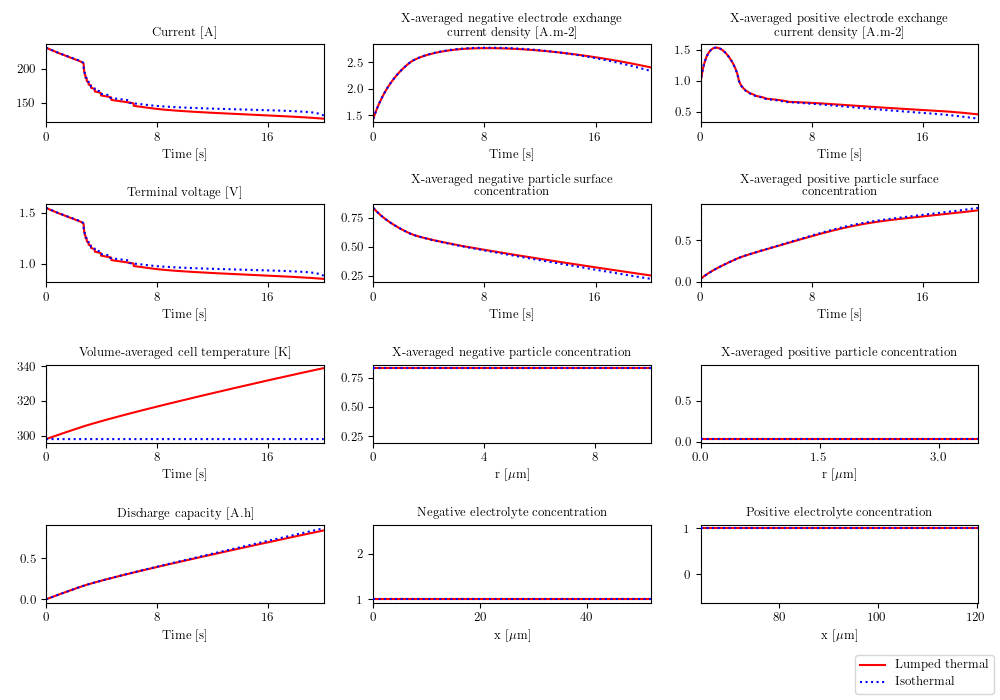

In [37]:
# solution = solutions[0]
quick_plot = pybamm.QuickPlot(solutions, figsize=[10,7],n_rows = 4, labels = ['Lumped thermal', 'Isothermal'], output_variables=[ 
    'Current [A]', 
    'X-averaged negative electrode exchange current density [A.m-2]',
    'X-averaged positive electrode exchange current density [A.m-2]',

    'Terminal voltage [V]',
    'X-averaged negative particle surface concentration',
    'X-averaged positive particle surface concentration',

    'Volume-averaged cell temperature [K]',
    'X-averaged negative particle concentration', 
    'X-averaged positive particle concentration',

    'Discharge capacity [A.h]',
    'Negative electrolyte concentration',
    'Positive electrolyte concentration',
    ])
quick_plot.dynamic_plot()